In [31]:
#load packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

In [32]:
#import new dataset (bd patients with lab results after diagnosis)
os.chdir(r"C:\Users\selen\OneDrive\Desktop\BD_data")
df = pd.read_csv("bd_labs_only_after.csv")

In [33]:
#check total missing values per variable
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

GLUCOSE TOLERANCE    1388
INR                   987
HBA1C                 970
LDL                   750
HDL                   723
TOTAL CHOLESTEROL     683
FASTING GLUCOSE       665
dtype: int64

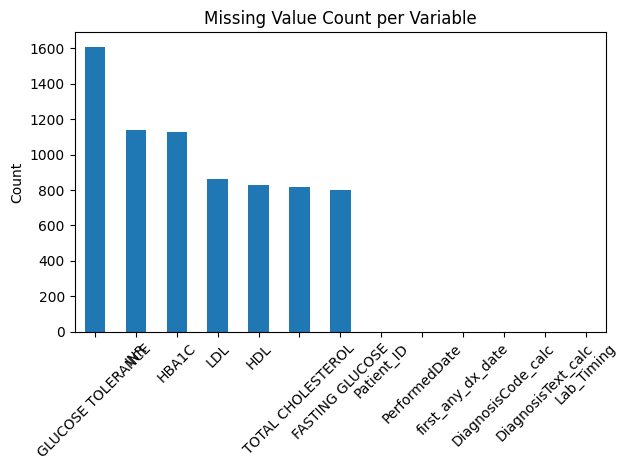

In [23]:
#visualizing missing data counts for each variable
missing_counts.plot.bar()
plt.title("Missing Value Count per Variable")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# checking how many variables have less than 50% missing data
threshold = 0.5 * len(df)
vars_greater_than_50 = missing_counts[missing_counts < threshold].index.tolist()
print("Variables with less than 50% missing data:", vars_greater_than_50)

#only two lab markers is not enough, so we will conduct two analyses: one with two lab markers, and one with all seven.


Variables with less than 50% missing data: ['FASTING GLUCOSE', 'Patient_ID', 'PerformedDate', 'first_any_dx_date', 'DiagnosisCode_calc', 'DiagnosisText_calc', 'Lab_Timing']


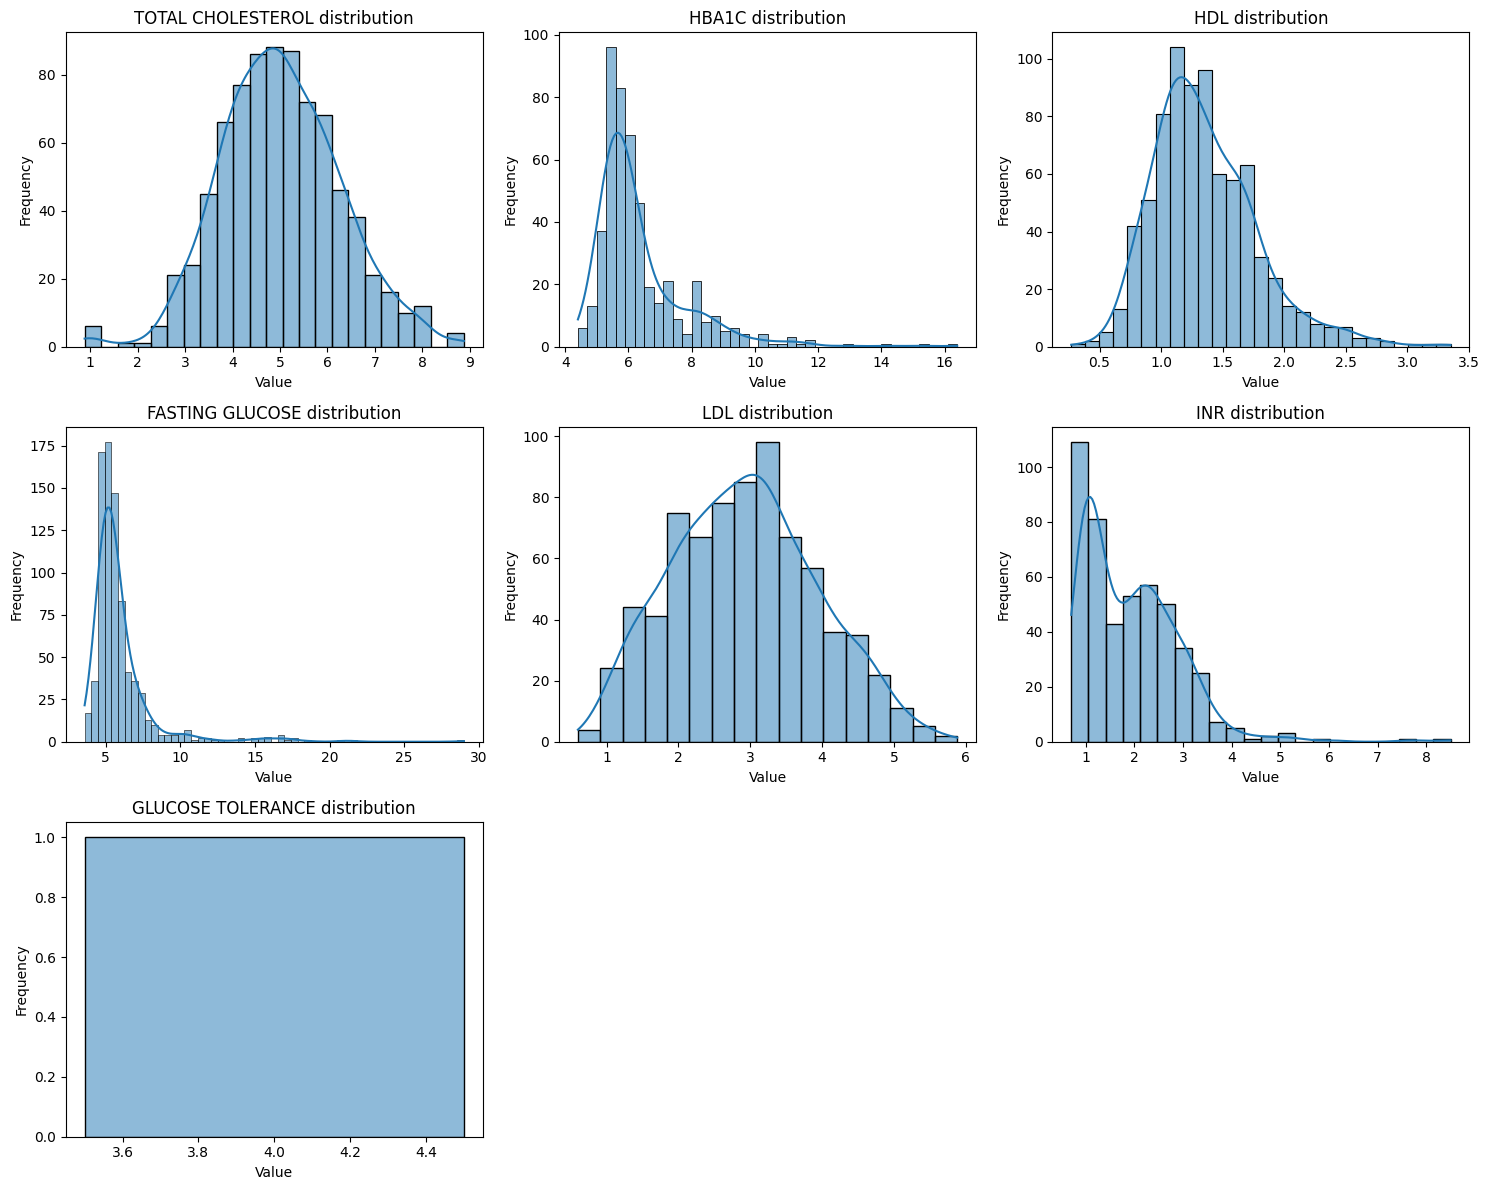

In [25]:
#checking distribution of all seven lab markers to determine if imputation should be done with mean or median
lab_cols = [
    "TOTAL CHOLESTEROL", "HBA1C", "HDL", 
    "FASTING GLUCOSE", "LDL", "INR", "GLUCOSE TOLERANCE"
]

n_cols = 3
n_rows = -(-len(lab_cols) // n_cols)  
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(lab_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} distribution")
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#impute with mean: TOTAL CHOLESTEROL, LDL, GLUCOSE TOLERANCE
#impute with median: HBA1C, HDL, FASTING GLUCOSE, INR

In [27]:
#creating dataset with only two labmarkers
two_cols = ["TOTAL CHOLESTEROL", "FASTING GLUCOSE"]
other_cols = ["Patient_ID", "PerformedDate", "first_any_dx_date", "DiagnosisCode_calc", "DiagnosisText_calc", "Lab_Timing"]
df_two_vars = df[other_cols + two_cols].copy()

#imputing total cholesterol with mean and fasting glucose with median
df_two_vars["TOTAL CHOLESTEROL"] = df_two_vars["TOTAL CHOLESTEROL"].fillna(df_two_vars["TOTAL CHOLESTEROL"].mean())
df_two_vars["FASTING GLUCOSE"] = df_two_vars["FASTING GLUCOSE"].fillna(df_two_vars["FASTING GLUCOSE"].median())
df_two_vars.to_csv("cleaned_dataset_two_vars.csv", index=False)

In [29]:
all_cols = ["TOTAL CHOLESTEROL", "FASTING GLUCOSE", "HBA1C", "HDL", "LDL", "INR", "GLUCOSE TOLERANCE"]
df_all_vars = df[other_cols + all_cols].copy()

impute_mean = ["TOTAL CHOLESTEROL", "LDL", "GLUCOSE TOLERANCE"]
impute_median = ["HBA1C", "HDL", "FASTING GLUCOSE", "INR"]
for col in impute_mean:
    df_all_vars[col] = df_all_vars[col].fillna(df_all_vars[col].mean())

for col in impute_median:
    df_all_vars[col] = df_all_vars[col].fillna(df_all_vars[col].median())

df_all_vars.to_csv("cleaned_dataset_all_vars.csv", index=False)